# Caso COVID-19 - Fase 1
## Gestión de Datos | Maestría en Ciencia de Datos

**Objetivo:** Analizar los datos de casos confirmados de COVID-19 de la Universidad Johns Hopkins
para responder las siguientes preguntas de interés:

1. ¿En cuál mes se presentó el mayor número de contagios?
2. ¿En ese mismo mes, cuál fue el país que reportó más contagios?
3. ¿Cuál es el país con el menor número de casos reportados hasta la fecha?

**Dataset:** Johns Hopkins University - COVID-19 Confirmed Cases (Global)

In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# 01. Load dataset and Check data
url = "https://raw.githubusercontent.com/CSSEGISandData/COVID-19/master/csse_covid_19_data/csse_covid_19_time_series/time_series_covid19_confirmed_global.csv"
df = pd.read_csv(url)
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns}")
df.head()

Shape: (289, 1147)
Columns: Index(['Province/State', 'Country/Region', 'Lat', 'Long', '1/22/20', '1/23/20',
       '1/24/20', '1/25/20', '1/26/20', '1/27/20',
       ...
       '2/28/23', '3/1/23', '3/2/23', '3/3/23', '3/4/23', '3/5/23', '3/6/23',
       '3/7/23', '3/8/23', '3/9/23'],
      dtype='object', length=1147)


,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,2/28/23,3/1/23,3/2/23,3/3/23,3/4/23,3/5/23,3/6/23,3/7/23,3/8/23,3/9/23
0,NaN,Afghanistan,33.93911,67.709953,0,0,0,0,0,0,...,209322,209340,209358,209362,209369,209390,209406,209436,209451,209451
1,NaN,Albania,41.15330,20.168300,0,0,0,0,0,0,...,334391,334408,334408,334427,334427,334427,334427,334427,334443,334457
2,NaN,Algeria,28.03390,1.659600,0,0,0,0,0,0,...,271441,271448,271463,271469,271469,271477,271477,271490,271494,271496
3,NaN,Andorra,42.50630,1.521800,0,0,0,0,0,0,...,47866,47875,47875,47875,47875,47875,47875,47875,47890,47890
4,NaN,Angola,-11.20270,17.873900,0,0,0,0,0,0,...,105255,105277,105277,105277,105277,105277,105277,105277,105288,105288


## 1. Exploración Inicial del Dataset

Antes de transformar los datos, exploramos su estructura general:
filas, columnas, tipos de datos y valores nulos.

In [6]:
# Dimensiones del dataset
print("Shape:", df.shape)

# Tipos de datos
print("\nData types:\n", df.dtypes.value_counts())

# Valores nulos por columna (solo las que tienen nulos)
nulls = df.isnull().sum()
print("\nColumns with null values:\n", nulls[nulls > 0])

# Últimas fechas registradas (las 5 más recientes)
date_columns = df.columns[4:]
print("\nLast 5 dates in dataset:", date_columns[-5:].tolist())
print("Most recent date:", date_columns[-1])

# Rename columns for clarity
df = df.rename(columns={
    'Country/Region': 'country',
    'Province/State': 'province'
})

df.head()

Shape: (289, 1147)

Data types:
 int64      1143
object        2
float64       2
Name: count, dtype: int64

Columns with null values:
 Province/State    198
Lat                 2
Long                2
dtype: int64

Last 5 dates in dataset: ['3/5/23', '3/6/23', '3/7/23', '3/8/23', '3/9/23']
Most recent date: 3/9/23


,province,country,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,2/28/23,3/1/23,3/2/23,3/3/23,3/4/23,3/5/23,3/6/23,3/7/23,3/8/23,3/9/23
0,NaN,Afghanistan,33.93911,67.709953,0,0,0,0,0,0,...,209322,209340,209358,209362,209369,209390,209406,209436,209451,209451
1,NaN,Albania,41.15330,20.168300,0,0,0,0,0,0,...,334391,334408,334408,334427,334427,334427,334427,334427,334443,334457
2,NaN,Algeria,28.03390,1.659600,0,0,0,0,0,0,...,271441,271448,271463,271469,271469,271477,271477,271490,271494,271496
3,NaN,Andorra,42.50630,1.521800,0,0,0,0,0,0,...,47866,47875,47875,47875,47875,47875,47875,47875,47890,47890
4,NaN,Angola,-11.20270,17.873900,0,0,0,0,0,0,...,105255,105277,105277,105277,105277,105277,105277,105277,105288,105288


### Exploración de variables

In [31]:
# Estadísticas descriptivas de las columnas numéricas
print("=== Descriptive Statistics ===")
print(df[['Lat', 'Long']].describe())

# Países únicos
print(f"\nUnique countries: {df['country'].nunique()}")

# Provincias con más registros
print("\nTop 5 provinces with most records:")
print(df['province'].value_counts().head())

# Porcentaje de nulos por columna
print("\nNull percentage per column:")
null_pct = (df.isnull().sum() / len(df) * 100).round(2)
print(null_pct[null_pct > 0])

# Países con provincia registrada vs sin provincia
print(f"\nCountries with province: {df['province'].notna().sum()}")
print(f"Countries without province: {df['province'].isna().sum()}")

=== Descriptive Statistics ===
              Lat        Long
count  287.000000  287.000000
mean    19.718719   22.182084
std     25.956609   77.870931
min    -71.949900 -178.116500
25%      4.072192  -32.823050
50%     21.512583   20.939400
75%     40.401784   89.224350
max     71.706900  178.065000

Unique countries: 201

Top 5 provinces with most records:
province
Australian Capital Territory    1
New South Wales                 1
Northern Territory              1
Queensland                      1
South Australia                 1
Name: count, dtype: int64

Null percentage per column:
province    68.51
Lat          0.69
Long         0.69
dtype: float64

Countries with province: 91
Countries without province: 198


In [32]:
# Países con más de un registro (tienen provincias)
print("=== Countries with multiple records (have provinces) ===")
print(df['country'].value_counts()[df['country'].value_counts() > 1])

# Valor mínimo, máximo y promedio de casos en la última fecha
last_date = date_columns[-1]
print(f"\n=== Confirmed cases stats on {last_date} ===")
print(f"  Max: {df[last_date].max():,.0f}")
print(f"  Min: {df[last_date].min():,.0f}")
print(f"  Mean: {df[last_date].mean():,.0f}")
print(f"  Median: {df[last_date].median():,.0f}")

=== Countries with multiple records (have provinces) ===
country
China             34
Canada            16
United Kingdom    15
France            12
Australia          8
Netherlands        5
New Zealand        3
Denmark            3
Name: count, dtype: int64

=== Confirmed cases stats on 3/9/23 ===
  Max: 103,802,702
  Min: 0
  Mean: 2,341,073
  Median: 103,248


### Hallazgos de la exploración inicial

El dataset cuenta con **201 países**, de los cuales 91 tienen registros
a nivel de provincia — principalmente China, Canadá y Reino Unido. El
68.51% de los registros no tienen provincia, por lo que el análisis
se realiza a nivel de país.

En cuanto a los casos confirmados al 9 de marzo de 2023, la diferencia
entre el máximo (103 millones) y la mediana (103,248) refleja una
distribución muy asimétrica — unos pocos países concentraron la gran
mayoría de los casos, mientras que la mayoría reportó cifras
considerablemente menores.

Los valores nulos en `Lat` y `Long` (0.69%) no representan un problema
para el análisis.

## 2. Transformación del Dataset

El dataset está en formato **wide** (cada fecha es una columna).
Para poder analizar por mes, lo convertimos a formato **long** usando `melt`,
donde cada fila representa un país, una fecha y su número de casos acumulados.

In [8]:
# Convertir de formato wide a long
df_long = df.melt(
    id_vars=['country', 'province'],
    value_vars=date_columns,
    var_name='date',
    value_name='confirmed_cases'
)
# Convertir la columna date a formato datetime (formato explícito para evitar el warning)
df_long['date'] = pd.to_datetime(df_long['date'], format='%m/%d/%y')

# Vista previa
print("Shape after melt:", df_long.shape)
df_long.head(10)

Shape after melt: (330327, 4)


,country,province,date,confirmed_cases
0,Afghanistan,NaN,2020-01-22,0
1,Albania,NaN,2020-01-22,0
2,Algeria,NaN,2020-01-22,0
3,Andorra,NaN,2020-01-22,0
4,Angola,NaN,2020-01-22,0
5,Antarctica,NaN,2020-01-22,0
6,Antigua and Barbuda,NaN,2020-01-22,0
7,Argentina,NaN,2020-01-22,0
8,Armenia,NaN,2020-01-22,0
9,Australia,Australian Capital Territory,2020-01-22,0


In [9]:
df_study = df_long.copy()

## 3. Análisis por Mes

Para calcular los contagios por mes, debemos tener en cuenta que los datos
son **acumulados**. Por ello, tomamos el **último valor reportado de cada mes**
por país, y luego calculamos la diferencia entre meses consecutivos para
obtener los casos nuevos de cada mes.

In [10]:
# Extraer el mes y año de la fecha
df_study['year_month'] = df_study['date'].dt.to_period('M')

# Tomar el último valor acumulado de cada país por mes
df_monthly = df_study.groupby(['country', 'year_month'])['confirmed_cases'].max().reset_index()

# Calcular casos nuevos por mes (diferencia entre meses consecutivos por país)
df_monthly['new_cases'] = df_monthly.groupby('country')['confirmed_cases'].diff().fillna(0)

# Vista previa
df_monthly.head(15)

,country,year_month,confirmed_cases,new_cases
0,Afghanistan,2020-01,0,0.0
1,Afghanistan,2020-02,5,5.0
2,Afghanistan,2020-03,166,161.0
3,Afghanistan,2020-04,1827,1661.0
4,Afghanistan,2020-05,15180,13353.0
5,Afghanistan,2020-06,31445,16265.0
6,Afghanistan,2020-07,36628,5183.0
7,Afghanistan,2020-08,38248,1620.0
8,Afghanistan,2020-09,39354,1106.0
9,Afghanistan,2020-10,41334,1980.0


## Pregunta 1: ¿En cuál mes se presentó el mayor número de contagios?

In [11]:
# Sumar los casos nuevos de todos los países por mes
df_by_month = df_monthly.groupby('year_month')['new_cases'].sum().reset_index()

# Encontrar el mes con mayor número de contagios
max_month = df_by_month.loc[df_by_month['new_cases'].idxmax()]

print("Month with highest number of new cases:")
print(f"  Month: {max_month['year_month']}")
print(f"  New cases: {max_month['new_cases']:,.0f}")

Month with highest number of new cases:
  Month: 2022-01
  New cases: 88,320,610


### Visualización: Casos nuevos por mes a nivel global

In [13]:
def plot_monthly_cases(df_by_month, peak_month):
    """
    Plots global COVID-19 new cases by month, highlighting the peak month.

    Parameters:
        df_by_month (DataFrame): Monthly aggregated new cases globally.
        peak_month (Series): Row containing the month with the highest cases.
    """
    df_plot = df_by_month.copy()
    df_plot['year_month_str'] = df_plot['year_month'].astype(str)
    peak_str = peak_month['year_month'].strftime('%Y-%m')

    plt.figure(figsize=(18, 6))
    sns.lineplot(data=df_plot, x='year_month_str', y='new_cases')
    plt.axvline(x=peak_str, color='red', linestyle='--', label=f'Peak: {peak_str}')
    plt.xticks(rotation=90)
    plt.title('Global COVID-19 New Cases by Month')
    plt.xlabel('Month')
    plt.ylabel('New Cases')
    plt.legend()
    plt.tight_layout()
    plt.show()

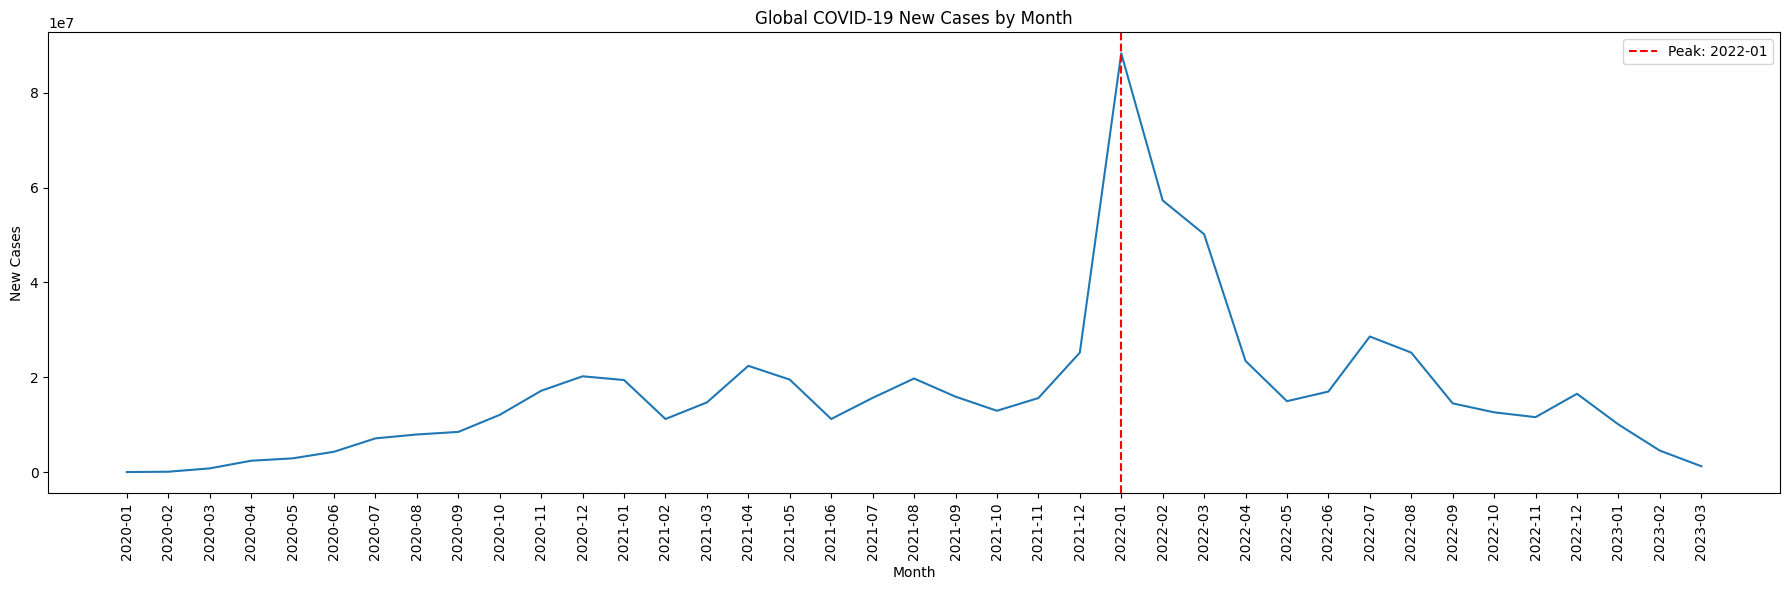

In [14]:
plot_monthly_cases(df_by_month, max_month)

## Pregunta 2: En enero 2022, ¿cuál fue el país que reportó más contagios?

In [15]:
# Filtrar solo el mes pico
df_peak_month = df_monthly[df_monthly['year_month'] == max_month['year_month']]

# Agrupar por país y sumar casos nuevos
df_peak_by_country = df_peak_month.groupby('country')['new_cases'].sum().reset_index()

# País con más contagios en ese mes
max_country = df_peak_by_country.loc[df_peak_by_country['new_cases'].idxmax()]

print(f"Country with most cases in {max_month['year_month']}:")
print(f"  Country: {max_country['country']}")
print(f"  New cases: {max_country['new_cases']:,.0f}")

Country with most cases in 2022-01:
  Country: US
  New cases: 20,336,435


### Visualización: Top 10 países con más contagios en enero 2022

In [18]:
def plot_top_countries(df_peak_by_country, peak_month, top_n=10):
    """
    Plots the top N countries with the most new cases in the peak month.

    Parameters:
        df_peak_by_country (DataFrame): New cases by country for the peak month.
        peak_month (Series): Row containing the peak month info.
        top_n (int): Number of top countries to display.
    """
    df_top = df_peak_by_country.nlargest(top_n, 'new_cases')

    plt.figure(figsize=(12, 6))
    sns.barplot(data=df_top, x='new_cases', y='country', hue='country', palette='flare', legend=False)
    plt.title(f'Top {top_n} Countries - New Cases in {peak_month["year_month"]}')
    plt.xlabel('New Cases')
    plt.ylabel('Country')
    plt.tight_layout()
    plt.show()

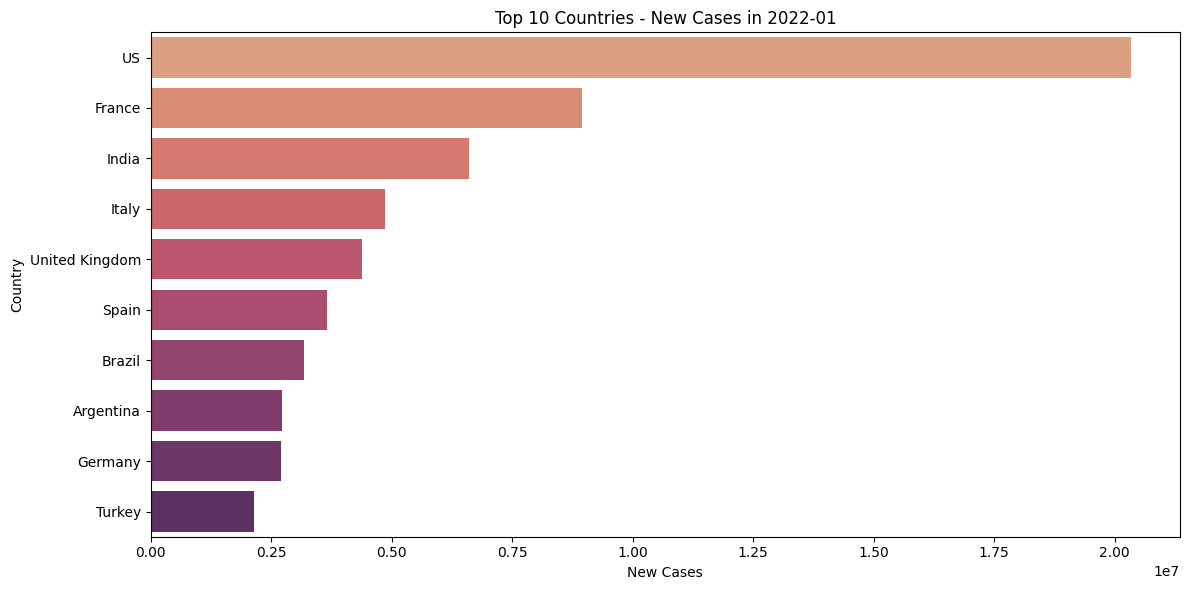

In [19]:
plot_top_countries(df_peak_by_country, max_month)

## Pregunta 3: ¿Cuál es el país con el menor número de casos reportados hasta la fecha?

La "fecha" corresponde al último registro del dataset: **March 9, 2023**.
Como los datos son acumulados, tomamos el valor de la última fecha disponible
por país, que representa el total de casos confirmados hasta ese día.

In [23]:
last_dates = sorted(df_long['date'].unique(), reverse=True)[:5]
print("Last 5 reporting dates in the dataset:")
for d in last_dates:
    print(f"  {pd.Timestamp(d).strftime('%B %d, %Y')}")

Last 5 reporting dates in the dataset:
  March 09, 2023
  March 08, 2023
  March 07, 2023
  March 06, 2023
  March 05, 2023


In [24]:
# Tomar el último valor acumulado por país (última fecha del dataset)
df_latest = df_long.groupby('country')['confirmed_cases'].max().reset_index()

# Excluir países con 0 casos (sin reporte)
df_latest = df_latest[df_latest['confirmed_cases'] > 0]

# País con menor número de casos
min_country = df_latest.loc[df_latest['confirmed_cases'].idxmin()]

print("Country with the lowest number of confirmed cases to date:")
print(f"  Country: {min_country['country']}")
print(f"  Confirmed cases: {min_country['confirmed_cases']:,.0f}")

Country with the lowest number of confirmed cases to date:
  Country: Korea, North
  Confirmed cases: 1


### Visualización: 10 países con menos casos confirmados hasta marzo de 2023

In [29]:
def plot_bottom_countries(df_latest, top_n=10):
    """
    Plots the bottom N countries with the lowest confirmed cases to date.

    Parameters:
        df_latest (DataFrame): Total confirmed cases by country (latest date).
        top_n (int): Number of bottom countries to display.
    """
    df_bottom = df_latest.nsmallest(top_n, 'confirmed_cases')

    plt.figure(figsize=(12, 6))
    ax = sns.barplot(data=df_bottom, x='confirmed_cases', y='country', hue='country', palette='flare', legend=False)

    # Agregar el número exacto al lado de cada barra
    for container in ax.containers:
        ax.bar_label(container, fmt='{:,.0f}', padding=5, fontsize=10)

    plt.title(f'Bottom {top_n} países - Casos confirmados hasta la fecha (9 de marzo de 2023)')
    plt.xlabel('Casos confirmados')
    plt.ylabel('País')
    plt.tight_layout()
    plt.show()

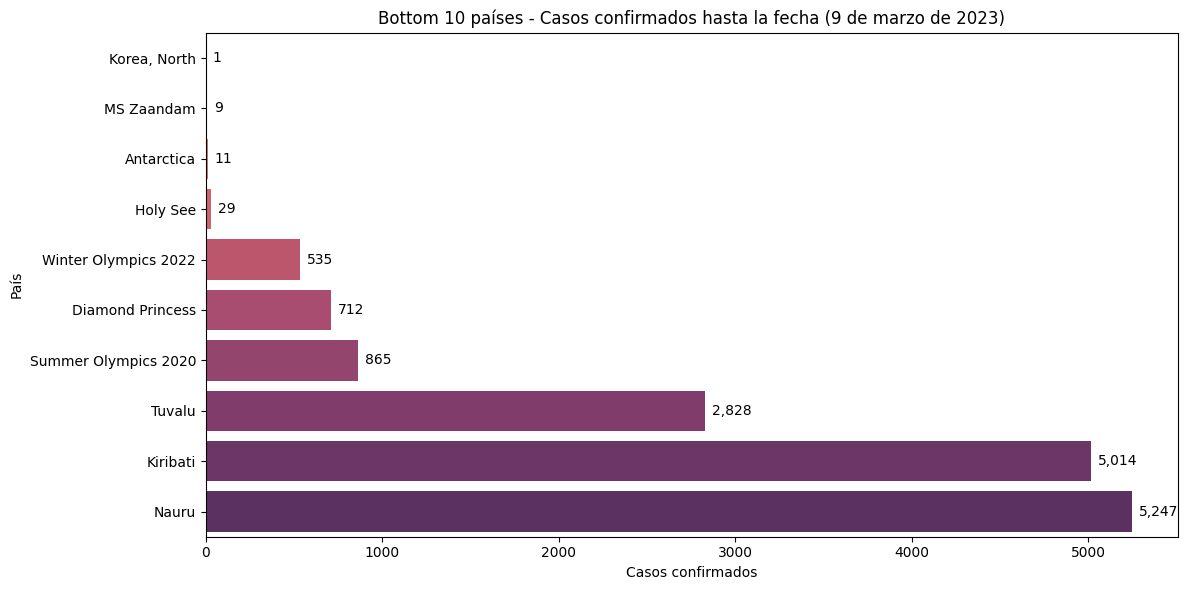

In [30]:
plot_bottom_countries(df_latest)

## Conclusiones

Para el análisis, se usaron las bibliotecas `pandas` para la preparación y limpieza
de datos, y `seaborn` para las visualizaciones, por preferencia personal sobre `matplotlib`.

El dataset fue transformado de formato ancho a largo con `melt`, dado que cada columna
era una fecha. Los valores nulos encontrados en `Province/State`, `Lat` y `Long`
no afectaron el análisis, pues se trabajó a nivel de país.

Las gráficas lo dicen todo, pero en resumen:

1. El mes con más contagios fue **enero de 2022**, con más de 88 millones de casos nuevos.

2. En ese mes, **Estados Unidos** fue el país con más casos, superando los **20 millones**.

3. El país con menos casos reportados hasta el 9 de marzo de 2023 es **Corea del Norte**,
con un solo caso.